In [1]:
import pandas as pd
df=pd.read_csv("Wholesale customers data.csv")
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [2]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [4]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [5]:
df['Channel'].unique()

array([2, 1])

In [6]:
df['Region'].unique()

array([3, 1, 2])

In [7]:
df.sample(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
335,2,2,27082,6817,10790,1365,4111,2139
316,1,2,7127,1375,2201,2679,83,1059
272,1,1,514,8323,6869,529,93,1040
150,1,3,16225,1825,1765,853,170,1067
178,1,3,11002,7075,4945,1152,120,395


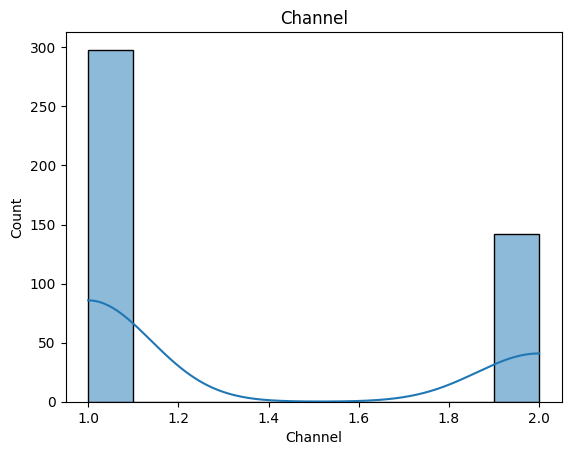

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Channel"],kde=True)
plt.title("Channel")
plt.show()

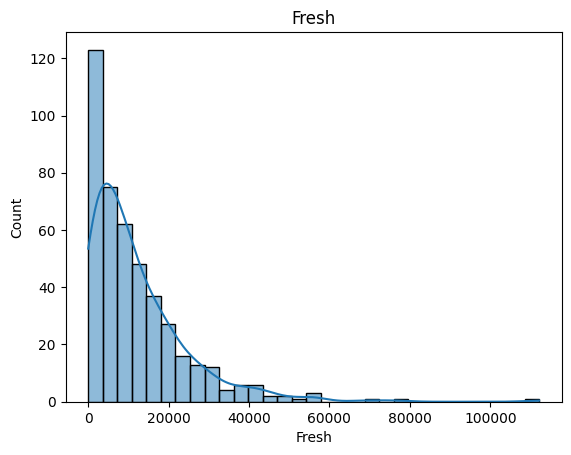

In [9]:
sns.histplot(df['Fresh'],kde=True)
plt.title("Fresh")
plt.show()

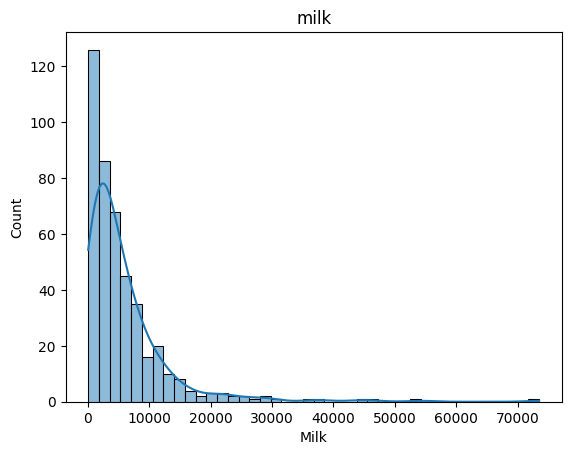

In [10]:
sns.histplot(df['Milk'],kde=True)
plt.title("milk")
plt.show()

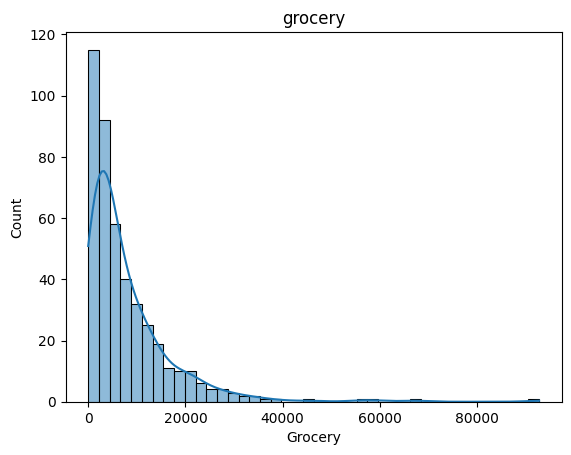

In [11]:
sns.histplot(df['Grocery'],kde=True)
plt.title("grocery")
plt.show()

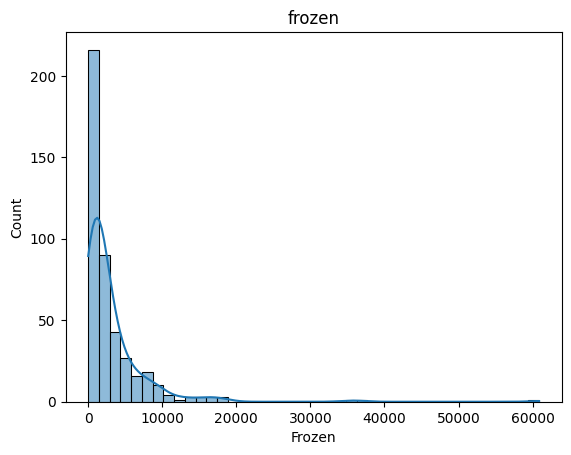

In [12]:
sns.histplot(df['Frozen'],kde=True)
plt.title("frozen")
plt.show()

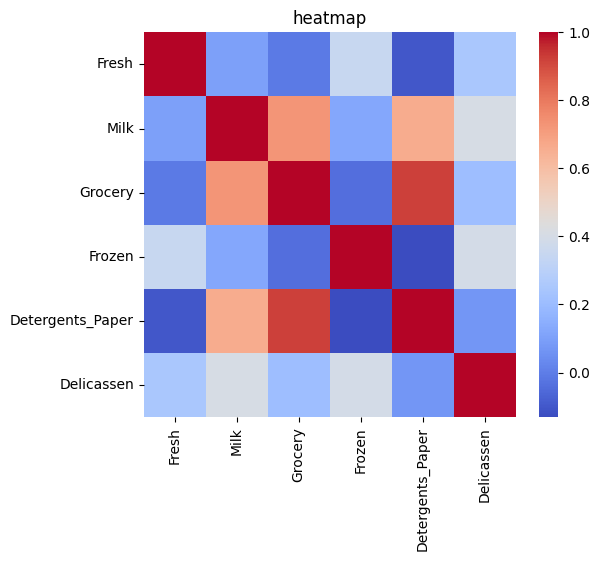

In [13]:
corr=df[[ 'Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,fmt=".2f",cmap="coolwarm")
plt.title("heatmap")
plt.show()

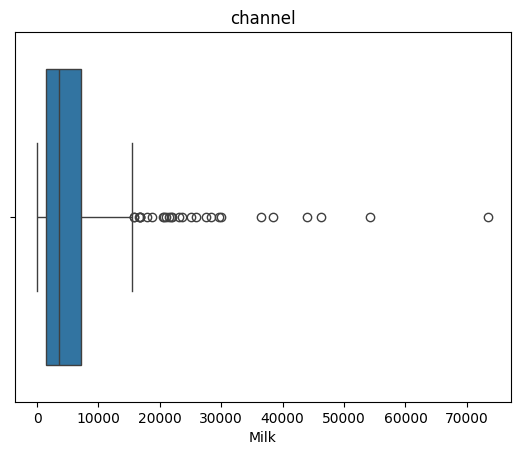

In [14]:
sns.boxplot(x=df['Milk'])
plt.title("channel")
plt.show()

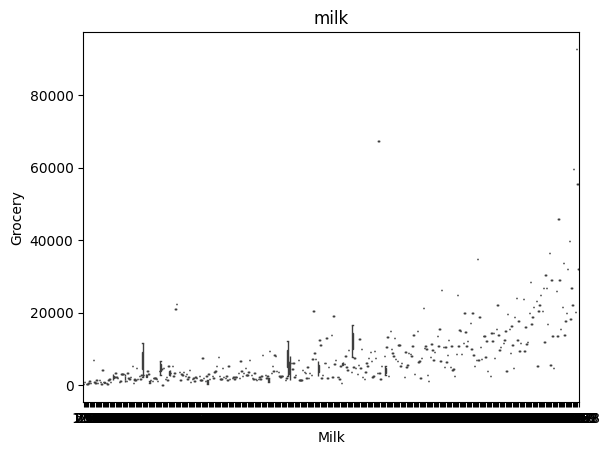

In [15]:
sns.boxplot(data=df,x="Milk",y="Grocery")
plt.title("milk")
plt.show()

In [16]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

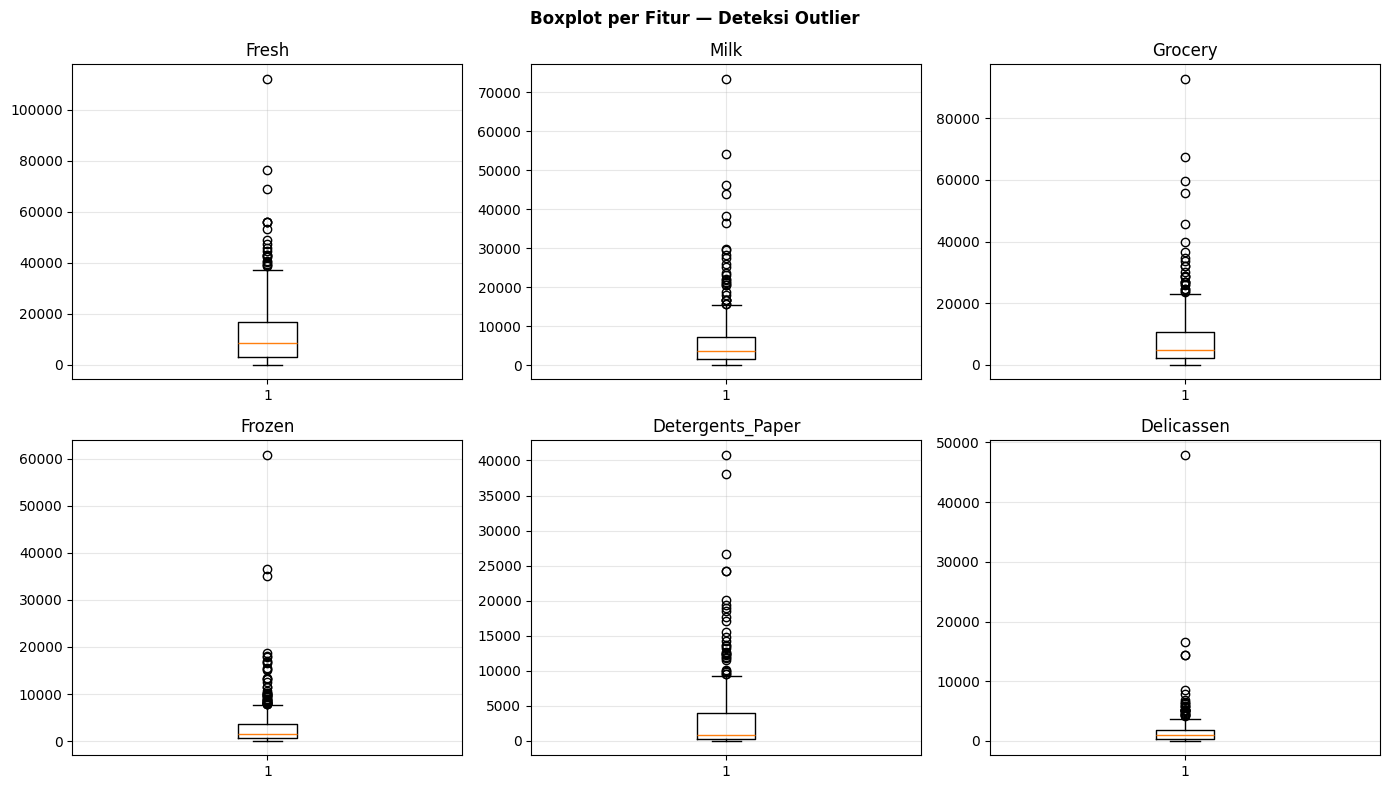


=== Jumlah Outlier per Fitur (metode IQR) ===
Fresh               : 20 outlier
Milk                : 28 outlier
Grocery             : 24 outlier
Frozen              : 43 outlier
Detergents_Paper    : 30 outlier
Delicassen          : 27 outlier


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

for i, feat in enumerate(features):
    ax = axes[i//3][i%3]
    ax.boxplot(df[feat])
    ax.set_title(feat)
    ax.grid(alpha=0.3)

plt.suptitle("Boxplot per Fitur — Deteksi Outlier", fontweight='bold')
plt.tight_layout()
plt.show()

# Hitung jumlah outlier per fitur pakai IQR
print("\n=== Jumlah Outlier per Fitur (metode IQR) ===")
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outlier = df[(df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)]
    print(f"{feat:20s}: {len(outlier)} outlier")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

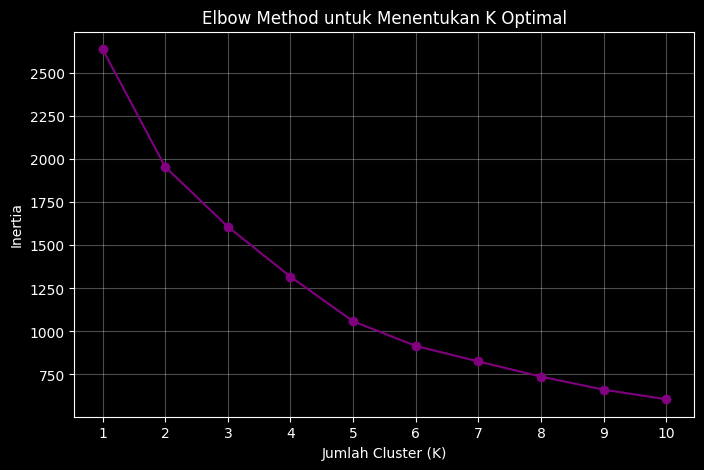

→ Elbow biasanya terlihat di sekitar K=3 pada dataset ini.



In [26]:
# -----------------------------
# Blok 4: Elbow Method (tanpa warning)
# -----------------------------
X = df[[ 'Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']]
X_array = X.to_numpy()              # Konversi ke numpy array sejak awal

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.style.use("dark_background")
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='purple')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan K Optimal")
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

print("→ Elbow biasanya terlihat di sekitar K=3 pada dataset ini.\n")


# -----------------------------

In [28]:
# Data yang sudah discaling (tanpa Channel & Region)
X_array = scaler.fit_transform(df[['Fresh', 'Milk', 'Grocery', 
                                    'Frozen', 'Detergents_Paper', 'Delicassen']])

# ── Model 1: K-Means ──
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
label_kmeans = kmeans.fit_predict(X_array)
sil_kmeans = silhouette_score(X_array, label_kmeans)

# ── Model 2: Agglomerative Clustering ──
agglo = AgglomerativeClustering(n_clusters=3)
label_agglo = agglo.fit_predict(X_array)
sil_agglo = silhouette_score(X_array, label_agglo)

# ── Model 3: DBSCAN ──
dbscan = DBSCAN(eps=1.5, min_samples=5)
label_dbscan = dbscan.fit_predict(X_array)
sil_dbscan = silhouette_score(X_array, label_dbscan)

#note 
#tidak memakai agglo karna hasil sillhouette score nya kecil 
#tidak memakai DBscan karna ada banyak outlier yang menyebabkan dbscan kurang memadai untuk di pakai di data set ini 

# ── Perbandingan ──
print("=== Perbandingan Silhouette Score ===")
print(f"K-Means              : {sil_kmeans:.4f}")
print(f"Agglomerative        : {sil_agglo:.4f}")
print(f"DBSCAN               : {sil_dbscan:.4f}")

=== Perbandingan Silhouette Score ===
K-Means              : 0.5472
Agglomerative        : 0.2646
DBSCAN               : 0.6602


In [29]:
# Rata-rata K-Means
df['cluster_kmeans'] = label_kmeans
print("K-Means:")
print(df.groupby('cluster_kmeans')[['Fresh', 'Milk', 'Grocery',
                                     'Frozen', 'Detergents_Paper', 
                                     'Delicassen']].mean().round(0))

# Rata-rata Agglomerative
df['cluster_agglo'] = label_agglo
print("\nAgglomerative:")
print(df.groupby('cluster_agglo')[['Fresh', 'Milk', 'Grocery',
                                    'Frozen', 'Detergents_Paper', 
                                    'Delicassen']].mean().round(0))

# Rata-rata DBSCAN
df['cluster_dbscan'] = label_dbscan
print("\nDBSCAN:")
print(df.groupby('cluster_dbscan')[['Fresh', 'Milk', 'Grocery',
                                     'Frozen', 'Detergents_Paper', 
                                     'Delicassen']].mean().round(0))

K-Means:
                  Fresh     Milk  Grocery  Frozen  Detergents_Paper  \
cluster_kmeans                                                        
0               12157.0   4028.0   5403.0  3066.0            1668.0   
1               10803.0  19282.0  27390.0  3117.0           12140.0   

                Delicassen  
cluster_kmeans              
0                   1257.0  
1                   3569.0  

Agglomerative:
                 Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster_agglo                                                                 
0              27477.0  43542.0  54588.0  8286.0           25018.0     10248.0
1              15049.0   3017.0   3792.0  3837.0             758.0      1310.0
2               5794.0   9420.0  13762.0  1462.0            5913.0      1578.0

DBSCAN:
                  Fresh     Milk  Grocery   Frozen  Detergents_Paper  \
cluster_dbscan                                                         
-1              27309.0  2

In [35]:
# Cek model yang tersimpan
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

model = joblib.load("cluster.joblib")
df = pd.read_csv("Wholesale customers data.csv")
FITUR = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

# Cek predict pakai values
df_test = df[FITUR].copy()
hasil = model.predict(df_test.values)
print("Pakai .values:", pd.Series(hasil).value_counts())

# Cek predict tanpa values
hasil2 = model.predict(df_test)
print("Tanpa .values:", pd.Series(hasil2).value_counts())

# Cek scaler di dalam pipeline
scaler = model.named_steps['scaler']
print("\nScaler mean:", scaler.mean_)
print("Scaler fitur:", scaler.feature_names_in_ if hasattr(scaler, 'feature_names_in_') else "Tidak ada nama fitur")

Pakai .values: 2    398
0     42
Name: count, dtype: int64
Tanpa .values: 2    398
0     42
Name: count, dtype: int64

Scaler mean: [-3.43159844e-17  0.00000000e+00 -4.03717464e-17  3.63345717e-17
  2.42230478e-17 -8.07434927e-18]
Scaler fitur: Tidak ada nama fitur


C:\Users\LENOVO\mesin\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


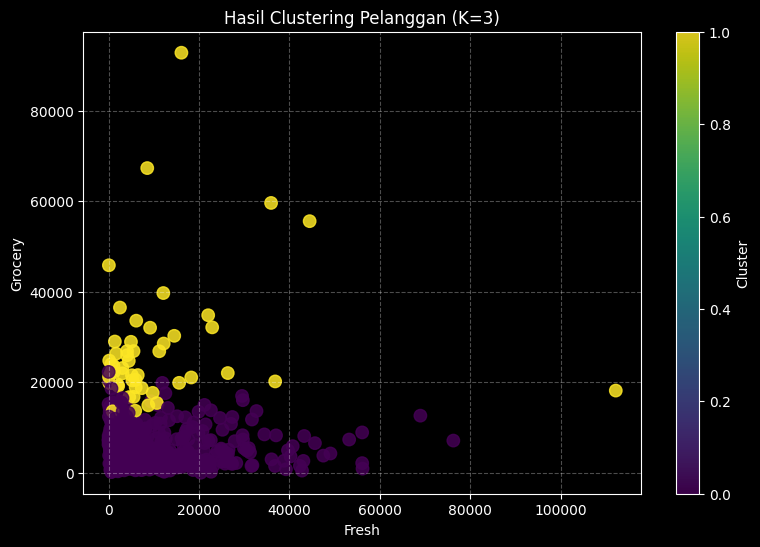


Rata-rata per Cluster:
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0        12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
1        10803.0  19282.0  27390.0  3117.0           12140.0      3569.0
None


In [30]:
# Blok 5: Pipeline Clustering + Visualisasi Hasil (tanpa warning)
# -----------------------------
model = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2,random_state=42,n_init=10))
])

# Fit dengan numpy array → scaler tidak simpan nama kolom → NO WARNING
model.fit(X_array)

# Label cluster
labels = model.named_steps['kmeans'].labels_

# Tambah ke df untuk analisis & visualisasi
df['cluster'] = labels

# Visualisasi hasil clustering
plt.style.use('dark_background')
plt.figure(figsize=(9, 6))
scatter = plt.scatter( 
    df['Fresh'],
    df['Grocery'], 
    c=labels,
    cmap='viridis',
    s=80,
    alpha=0.85
)
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("Hasil Clustering Pelanggan (K=3)")
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# Ringkasan rata-rata per cluster
print("\nRata-rata per Cluster:")
print(print(df.groupby('cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean().round(0)))

Pakai .values: 2    398
0     42
Name: count, dtype: int64
Tanpa .values: 2    398
0     42
Name: count, dtype: int64

Scaler mean: [-3.43159844e-17  0.00000000e+00 -4.03717464e-17  3.63345717e-17
  2.42230478e-17 -8.07434927e-18]
Scaler fitur: Tidak ada nama fitur


C:\Users\LENOVO\mesin\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [31]:
# Blok 6: Silhouette Score (tanpa warning)
# -----------------------------
# Transform pakai numpy array yang sama
X_scaled_final = model.named_steps['scaler'].transform(X_array)

sil_score = silhouette_score(X_scaled_final, labels)
print(f"\nSilhouette Score (K=3): {sil_score:.4f}")

if sil_score > 0.5:
    print("→ Cluster cukup terpisah dengan baik")
elif sil_score > 0.3:
    print("→ Cluster cukup wajar (ada sedikit overlap)")
else:
    print("→ Cluster kurang optimal, coba ubah jumlah K")


# -----------------------------


Silhouette Score (K=3): 0.5472
→ Cluster cukup terpisah dengan baik


In [32]:
# Blok 7: Prediksi Data Baru (tanpa warning)
# -----------------------------
data_baru = np.array([[9789.0,5712.0,7128.0,12876.0,1287.0,7897.0]])

pred_clusters = model.predict(data_baru)

print("\n=== Prediksi Data Baru ===")

print(f"Cluster {pred_clusters[0]}")



=== Prediksi Data Baru ===
Cluster 1


In [36]:
import joblib
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load data
df = pd.read_csv("Wholesale customers data.csv")
FITUR = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

# 2. Ambil data asli — JANGAN pakai data yang sudah discale
X = df[FITUR].values  # pakai numpy array langsung

# 3. Cek data aslinya dulu
print("Sample data asli:")
print(df[FITUR].head())
print("\nMean data asli:", df[FITUR].mean().values)

# 4. Train model baru
model_baru = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, random_state=42, n_init=10))
])
model_baru.fit(X)

# 5. Cek scaler mean — harusnya ribuan
print("\nScaler mean setelah fit:", model_baru.named_steps['scaler'].mean_)

# 6. Cek hasil cluster
labels = model_baru.predict(X)
print("\nHasil cluster:", pd.Series(labels).value_counts())

# 7. Simpan model baru
joblib.dump(model_baru, "cluster3.joblib")
print("\nModel berhasil disimpan!")

Sample data asli:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185

Mean data asli: [12000.29772727  5796.26590909  7951.27727273  3071.93181818
  2881.49318182  1524.87045455]

Scaler mean setelah fit: [12000.29772727  5796.26590909  7951.27727273  3071.93181818
  2881.49318182  1524.87045455]

Hasil cluster: 0    389
1     51
Name: count, dtype: int64

Model berhasil disimpan!


In [37]:
df["Cluster"] = labels
print(df.groupby("Cluster")[FITUR].mean().round(0))


           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0        12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
1        10803.0  19282.0  27390.0  3117.0           12140.0      3569.0


In [33]:
import joblib
joblib.dump(model,"cluster2.joblib")

['cluster2.joblib']